In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)

from qd_solve import *
from qd_solve.eig import *
from qd_solve.operator import *
from qd_solve.split import *
from qd_solve.system import *
from qd_solve.timestepper import *
from qd_solve.spaces.pseudospectral import *
from qd_solve.spaces.finite_difference import *
from qd_solve.exp import *

from miscutils.plot import animate

import jax.numpy as jnp
import diffrax

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [8]:
x0 = jnp.array([-10, -10])
xf = jnp.array([10, 10])
mesh_size = (100, 100)
num_modes = (100, 100)

space = FiniteDifferenceND(x0, xf, mesh_size)
space

FiniteDifferenceND(x0=(-10.0, -10.0), xf=(10.0, 10.0), mesh_size=(100, 100))

In [9]:
type(space.mesh_size)

tuple

In [10]:
potential_fn = lambda x: jnp.linalg.norm(x) ** 2
potential_vals = space.eval(potential_fn)
y = space.from_values(potential_vals)
X, Y = space.x_ranges

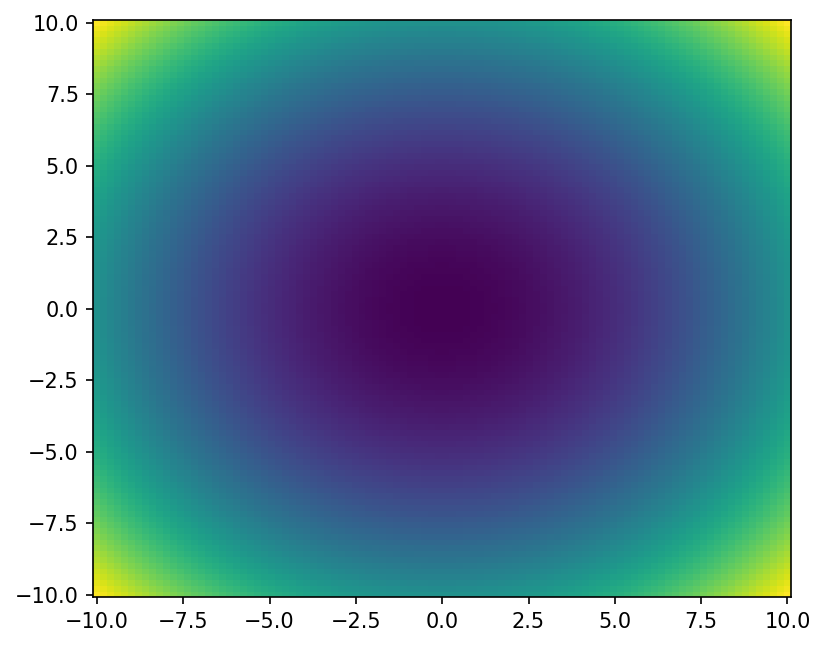

In [11]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.pcolormesh(X, Y, potential_vals)

plt.show()
plt.close(fig)

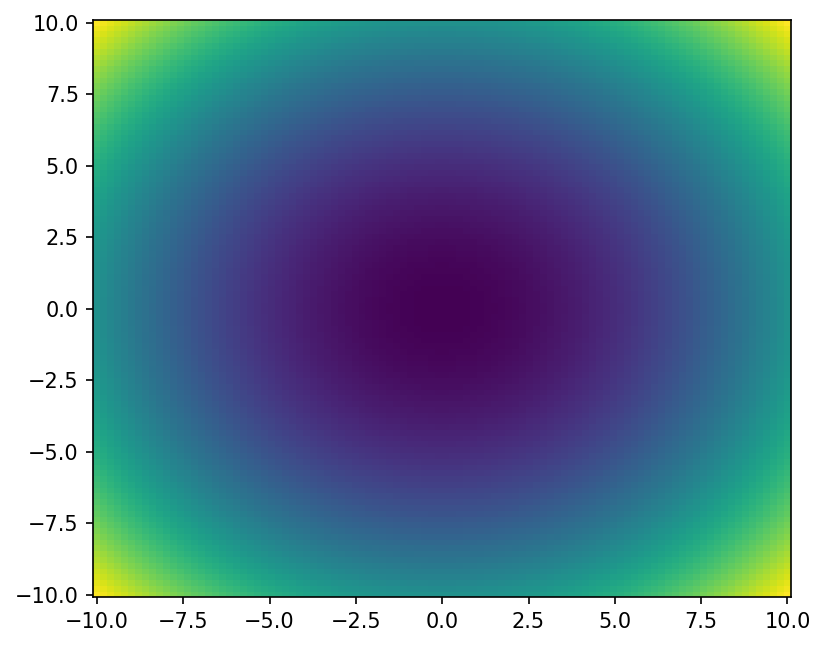

In [12]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.pcolormesh(X, Y, jnp.real(y.values))

plt.show()
plt.close(fig)

In [13]:
jnp.linalg.norm(potential_vals - y.values)

Array(0., dtype=float64)